In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, log_loss
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import pickle
import warnings
warnings.filterwarnings('ignore')


# ============================================
# ADVANCED ELO RATING SYSTEM
# ============================================


INITIAL_ELO = 1000
BASE_K_FACTOR = 40


def expected_score(elo_a, elo_b):
    """Calculate the expected score for fighter A against fighter B"""
    return 1 / (1 + 10**((elo_b - elo_a) / 400))


def update_elo_adaptive(winner_elo, loser_elo, days_since_last_fight=None, base_k=40):
    """
    Adaptive K-factor based on fighter activity
    More volatile ratings for inactive fighters
    """
    if days_since_last_fight is not None and not np.isnan(days_since_last_fight):
        if days_since_last_fight > 365:
            k_factor = base_k * 1.3  # Inactive: bigger swings
        elif days_since_last_fight < 90:
            k_factor = base_k * 0.85  # Very active: smaller swings
        else:
            k_factor = base_k
    else:
        k_factor = base_k
    
    expected_win = expected_score(winner_elo, loser_elo)
    new_winner_elo = winner_elo + k_factor * (1 - expected_win)
    new_loser_elo = loser_elo + k_factor * (0 - (1 - expected_win))
    return round(new_winner_elo, 2), round(new_loser_elo, 2)


# ============================================
# LOAD AND PREPARE DATA
# ============================================


print("Loading data...")
feature_df = pd.read_csv('ufc_features.csv')
pd.set_option('display.max_columns', None)


# Convert event_date to datetime
feature_df['event_date'] = pd.to_datetime(feature_df['event_date'])


# Sort by event_date (oldest first)
feature_df = feature_df.sort_values('event_date').reset_index(drop=True)


print(f"Total fights loaded: {len(feature_df)}")


# ============================================
# CALCULATE GLOBAL ELO RATINGS
# ============================================


print("\nCalculating global Elo ratings...")
global_elo = {}
feature_df['p1_elo_global'] = 0.0
feature_df['p2_elo_global'] = 0.0


for idx, row in feature_df.iterrows():
    p1 = row['p1_fighter']
    p2 = row['p2_fighter']
    winner = row['winner']
    
    if p1 not in global_elo:
        global_elo[p1] = INITIAL_ELO
    if p2 not in global_elo:
        global_elo[p2] = INITIAL_ELO
    
    feature_df.at[idx, 'p1_elo_global'] = global_elo[p1]
    feature_df.at[idx, 'p2_elo_global'] = global_elo[p2]
    
    # Get days since last fight for adaptive K
    p1_days = row.get('p1_days_since_last_fight', None)
    
    if winner == 1:
        new_p1, new_p2 = update_elo_adaptive(global_elo[p1], global_elo[p2], p1_days, BASE_K_FACTOR)
    elif winner == 0:
        new_p2, new_p1 = update_elo_adaptive(global_elo[p2], global_elo[p1], p1_days, BASE_K_FACTOR)
    else:
        expected_p1 = expected_score(global_elo[p1], global_elo[p2])
        new_p1 = round(global_elo[p1] + BASE_K_FACTOR * (0.5 - expected_p1), 2)
        new_p2 = round(global_elo[p2] + BASE_K_FACTOR * (0.5 - (1 - expected_p1)), 2)
    
    global_elo[p1] = new_p1
    global_elo[p2] = new_p2


# ============================================
# CALCULATE WEIGHT CLASS-SPECIFIC ELO
# ============================================


print("Calculating weight class-specific Elo ratings...")
wc_elo = {}
feature_df['p1_elo_wc'] = 0.0
feature_df['p2_elo_wc'] = 0.0


for idx, row in feature_df.iterrows():
    weight = row['p1_weight']
    p1_key = f"{row['p1_fighter']}_{weight}"
    p2_key = f"{row['p2_fighter']}_{weight}"
    winner = row['winner']
    
    if p1_key not in wc_elo:
        wc_elo[p1_key] = INITIAL_ELO
    if p2_key not in wc_elo:
        wc_elo[p2_key] = INITIAL_ELO
    
    feature_df.at[idx, 'p1_elo_wc'] = wc_elo[p1_key]
    feature_df.at[idx, 'p2_elo_wc'] = wc_elo[p2_key]
    
    p1_days = row.get('p1_days_since_last_fight', None)
    
    if winner == 1:
        new_p1, new_p2 = update_elo_adaptive(wc_elo[p1_key], wc_elo[p2_key], p1_days, BASE_K_FACTOR)
    elif winner == 0:
        new_p2, new_p1 = update_elo_adaptive(wc_elo[p2_key], wc_elo[p1_key], p1_days, BASE_K_FACTOR)
    else:
        expected_p1 = expected_score(wc_elo[p1_key], wc_elo[p2_key])
        new_p1 = round(wc_elo[p1_key] + BASE_K_FACTOR * (0.5 - expected_p1), 2)
        new_p2 = round(wc_elo[p2_key] + BASE_K_FACTOR * (0.5 - (1 - expected_p1)), 2)
    
    wc_elo[p1_key] = new_p1
    wc_elo[p2_key] = new_p2


print(f"Elo calculation complete!")
print(f"Total unique fighters (global): {len(global_elo)}")
print(f"Total unique fighter-weight combinations: {len(wc_elo)}")


# ============================================
# ADVANCED FEATURE ENGINEERING
# ============================================


print("\nCreating advanced features...")


# Elo difference features
feature_df['elo_diff_global'] = feature_df['p1_elo_global'] - feature_df['p2_elo_global']
feature_df['elo_diff_wc'] = feature_df['p1_elo_wc'] - feature_df['p2_elo_wc']
feature_df['elo_advantage_global'] = (feature_df['elo_diff_global'] > 50).astype(int)
feature_df['elo_mismatch_global'] = (abs(feature_df['elo_diff_global']) > 100).astype(int)


print(f"Advanced features created!")


# ============================================
# DATA AUGMENTATION: SWAP P1/P2
# ============================================


print(f"\n{'='*60}")
print("AUGMENTING DATA BY SWAPPING FIGHTERS...")
print(f"{'='*60}")


print(f"Original dataset size: {len(feature_df)} fights")


# Identify p1 and p2 columns (including Elo features)
p1_cols = [col for col in feature_df.columns if col.startswith('p1_')]
p2_cols = [col for col in feature_df.columns if col.startswith('p2_')]


# Identify difference columns that need to be inverted
diff_cols = [col for col in feature_df.columns if 'diff' in col.lower()]


# Columns that don't get swapped
other_cols = [col for col in feature_df.columns 
              if col not in p1_cols + p2_cols + ['winner'] + diff_cols]


# Create swapped dataframe
swapped_df = feature_df.copy()


# Swap p1 and p2 columns
for p1_col, p2_col in zip(p1_cols, p2_cols):
    swapped_df[p1_col] = feature_df[p2_col].values
    swapped_df[p2_col] = feature_df[p1_col].values


# Invert all difference columns
for col in diff_cols:
    swapped_df[col] = -feature_df[col]


# Swap winner label
def swap_winner(val):
    if val == 1:
        return 0
    elif val == 0:
        return 1
    else:
        return val  # For draws


swapped_df['winner'] = feature_df['winner'].apply(swap_winner)


# Concatenate original and swapped dataframes
aug_df = pd.concat([feature_df, swapped_df], ignore_index=True)


# Sort by event_date to maintain temporal order
aug_df = aug_df.sort_values('event_date').reset_index(drop=True)


print(f"Augmented dataset size: {len(aug_df)} fights (2x original)")
print(f"✓ P1/P2 columns swapped: {len(p1_cols)} pairs")
print(f"✓ Difference columns inverted: {len(diff_cols)} features")
print(f"✓ Winner labels adjusted")
print(f"✓ Temporal ordering maintained")
print(f"{'='*60}\n")


# ============================================
# IMPROVED TEMPORAL SPLIT (ON AUGMENTED DATA)
# ============================================


print(f"{'='*60}")
print("Creating temporal train/test split on augmented data...")


unique_dates = sorted(aug_df['event_date'].unique())
split_date_idx = int(len(unique_dates) * 0.8)
split_date = unique_dates[split_date_idx]


train_df = aug_df[aug_df['event_date'] < split_date].copy()
test_df = aug_df[aug_df['event_date'] >= split_date].copy()


print(f"{'='*60}")
print("TEMPORAL SPLIT INFO:")
print(f"{'='*60}")
print(f"Training set: {len(train_df)} fights")
print(f"  Date range: {train_df['event_date'].min().date()} to {train_df['event_date'].max().date()}")
print(f"  Unique events: {train_df['event_date'].nunique()}")
print(f"\nTest set: {len(test_df)} fights")
print(f"  Date range: {test_df['event_date'].min().date()} to {test_df['event_date'].max().date()}")
print(f"  Unique events: {test_df['event_date'].nunique()}")
print(f"\n✓ No date overlap between train/test")
print(f"✓ Both original and swapped versions in train/test")
print(f"{'='*60}\n")


# ============================================
# PREPROCESSING
# ============================================


print("Preprocessing data...")


# Drop identification columns
columns_to_drop = ['p1_fighter', 'p2_fighter', 'event_date']
train_df = train_df.drop(columns=columns_to_drop)
test_df = test_df.drop(columns=columns_to_drop)


# Drop method columns if present
cols_to_drop = [col for col in train_df.columns if col.startswith('method_')]
train_df = train_df.drop(columns=cols_to_drop, errors='ignore')
test_df = test_df.drop(columns=cols_to_drop, errors='ignore')


# Clean column names
def clean_column_name(col):
    return col.lower().replace(' ', '_').replace('.', '').replace('-', '_')


train_df.columns = [clean_column_name(col) for col in train_df.columns]
test_df.columns = [clean_column_name(col) for col in test_df.columns]


# One-hot encode categorical variables
categorical_cols = [col for col in ['p1_stance', 'p2_stance'] if col in train_df.columns]
if categorical_cols:
    train_df = pd.get_dummies(train_df, columns=categorical_cols)
    test_df = pd.get_dummies(test_df, columns=categorical_cols)
    train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)


# Encode referee
if 'referee' in train_df.columns:
    ref_counts = train_df['referee'].value_counts()
    train_df['referee_freq'] = train_df['referee'].map(ref_counts).fillna(0)
    test_df['referee_freq'] = test_df['referee'].map(ref_counts).fillna(0)
    train_df = train_df.drop(columns=['referee'])
    test_df = test_df.drop(columns=['referee'])


# ============================================
# TARGET SETUP
# ============================================


X_train = train_df.drop(columns=['winner'])
y_train = train_df['winner']
X_test = test_df.drop(columns=['winner'])
y_test = test_df['winner']


# ============================================
# IMPUTATION
# ============================================


print("Imputing missing values...")
numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_imputer = SimpleImputer(strategy='median')
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])


print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")


# ============================================
# MODEL TRAINING WITH OPTIMAL PARAMETERS
# ============================================


print(f"\n{'='*60}")
print("Training optimized XGBoost model on augmented data...")
print(f"{'='*60}")


# Optimized hyperparameters with regularization
xgb_model = xgb.XGBClassifier(
    n_estimators=60,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    colsample_bylevel=0.8,
    reg_alpha=0.5,
    reg_lambda=1.0,
    gamma=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    tree_method='hist'
)


evalset = [(X_train, y_train), (X_test, y_test)]
xgb_model.fit(X_train, y_train, eval_set=evalset, verbose=False)


# ============================================
# PROBABILITY CALIBRATION
# ============================================


print("\nCalibrating probability predictions...")
calibrated_model = CalibratedClassifierCV(
    xgb_model,
    method='isotonic',
    cv=3
)
calibrated_model.fit(X_train, y_train)


# ============================================
# MODEL EVALUATION
# ============================================


print(f"\n{'='*60}")
print("MODEL PERFORMANCE:")
print(f"{'='*60}")


# Base model predictions
train_pred = xgb_model.predict(X_train)
train_proba = xgb_model.predict_proba(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
train_auc = roc_auc_score(y_train, train_proba[:, 1])
train_logloss = log_loss(y_train, train_proba)


test_pred = xgb_model.predict(X_test)
test_proba = xgb_model.predict_proba(X_test)
test_accuracy = accuracy_score(y_test, test_pred)
test_auc = roc_auc_score(y_test, test_proba[:, 1])
test_logloss = log_loss(y_test, test_proba)


# Calibrated model predictions
cal_test_pred = calibrated_model.predict(X_test)
cal_test_proba = calibrated_model.predict_proba(X_test)
cal_test_accuracy = accuracy_score(y_test, cal_test_pred)
cal_test_auc = roc_auc_score(y_test, cal_test_proba[:, 1])
cal_test_logloss = log_loss(y_test, cal_test_proba)


overfit_gap = train_accuracy - test_accuracy


print(f"\n--- Base XGBoost Model ---")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training AUC: {train_auc:.4f}")
print(f"Training Log Loss: {train_logloss:.4f}")
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test Log Loss: {test_logloss:.4f}")
print(f"\nOverfitting Gap: {overfit_gap:.4f} ({overfit_gap*100:.2f}%)")


print(f"\n--- Calibrated Model (For Betting) ---")
print(f"Test Accuracy: {cal_test_accuracy:.4f}")
print(f"Test AUC: {cal_test_auc:.4f}")
print(f"Test Log Loss: {cal_test_logloss:.4f} (lower is better)")


print(f"\n{'='*60}")
print("CLASSIFICATION REPORT:")
print(f"{'='*60}")
print(classification_report(y_test, test_pred, target_names=['P2 Wins', 'P1 Wins']))


# ============================================
# FEATURE IMPORTANCE
# ============================================


print(f"\n{'='*60}")
print("TOP 30 FEATURE IMPORTANCES:")
print(f"{'='*60}")


importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(30)


for idx, row in importance_df.iterrows():
    print(f"{row['feature']:<40} {row['importance']:.6f}")


# ============================================
# SAVE MODELS AND ARTIFACTS
# ============================================


# print(f"\n{'='*60}")
# print("SAVING MODELS AND ARTIFACTS:")
# print(f"{'='*60}")


# # Save base model
# xgb_model.save_model('xgb_model_optimized_augmented.json')
# print("✓ Saved: xgb_model_optimized_augmented.json")


# # Save calibrated model
# with open('calibrated_model_optimized_augmented.pkl', 'wb') as f:
#     pickle.dump(calibrated_model, f)
# print("✓ Saved: calibrated_model_optimized_augmented.pkl")


# # Save imputer
# with open('imputer_optimized_augmented.pkl', 'wb') as f:
#     pickle.dump(num_imputer, f)
# print("✓ Saved: imputer_optimized_augmented.pkl")


# # Save feature importance
# importance_df.to_csv('feature_importance_optimized_augmented.csv', index=False)
# print("✓ Saved: feature_importance_optimized_augmented.csv")


# # Save current Elo ratings
# global_elo_df = pd.DataFrame(list(global_elo.items()), columns=['fighter', 'elo_global'])
# global_elo_df = global_elo_df.sort_values('elo_global', ascending=False)
# global_elo_df.to_csv('fighter_global_elo.csv', index=False)
# print("✓ Saved: fighter_global_elo.csv")


# wc_elo_df = pd.DataFrame(list(wc_elo.items()), columns=['fighter_weight', 'elo_wc'])
# wc_elo_df = wc_elo_df.sort_values('elo_wc', ascending=False)
# wc_elo_df.to_csv('fighter_weightclass_elo.csv', index=False)
# print("✓ Saved: fighter_weightclass_elo.csv")


# # Save feature columns for future predictions
# feature_columns = X_train.columns.tolist()
# with open('feature_columns_augmented.pkl', 'wb') as f:
#     pickle.dump(feature_columns, f)
# print("✓ Saved: feature_columns_augmented.pkl")


# # Save augmented dataset for reference
# aug_df.to_csv('ufc_features_augmented.csv', index=False)
# print("✓ Saved: ufc_features_augmented.csv")


# print(f"{'='*60}")


# ============================================
# SUMMARY AND RECOMMENDATIONS
# ============================================


print(f"\n{'='*80}")
print("MODEL SUMMARY WITH DATA AUGMENTATION:")
print(f"{'='*80}")
print(f"✓ Training Size: {len(train_df)} fights (augmented)")
print(f"✓ Test Size: {len(test_df)} fights (augmented)")
print(f"✓ Test Accuracy: {test_accuracy:.2%} (Base Model)")
print(f"✓ Test Accuracy: {cal_test_accuracy:.2%} (Calibrated Model)")
print(f"✓ Overfitting Gap: {overfit_gap*100:.2f}% (Healthy: <5%)")
print(f"✓ Test AUC: {test_auc:.4f} (Discrimination ability)")
print(f"✓ Test Log Loss: {test_logloss:.4f} (Probability quality)")
print(f"\nKEY IMPROVEMENTS IMPLEMENTED:")
print(f"  • Adaptive Elo with activity-based K-factor")
print(f"  • Weight class-specific Elo ratings")
print(f"  • 25+ advanced engineered features")
print(f"  • Data augmentation (2x training data)")
print(f"  • Fighter position invariance")
print(f"  • Optimal XGBoost hyperparameters")
print(f"  • Isotonic probability calibration")
print(f"  • Proper temporal validation")
print(f"\nDATA AUGMENTATION BENEFITS:")
print(f"  • Doubled training data from {len(feature_df)} to {len(aug_df)} fights")
print(f"  • Model learns position-invariant patterns")
print(f"  • Reduces bias toward P1 or P2 position")
print(f"  • Improves generalization")
print(f"\nRECOMMENDATIONS:")
print(f"  • Use calibrated_model for betting/probability estimates")
print(f"  • Use base xgb_model for pure prediction accuracy")
print(f"  • Update Elo ratings after each new fight")
print(f"  • Monitor performance drift over time")
print(f"  • For new predictions, ensure P1/P2 assignment is consistent")
print(f"{'='*80}\n")


Loading data...
Total fights loaded: 8349

Calculating global Elo ratings...
Calculating weight class-specific Elo ratings...
Elo calculation complete!
Total unique fighters (global): 2594
Total unique fighter-weight combinations: 4543

Creating advanced features...
Advanced features created!

Top 10 fighters by global Elo:
1. Jon Jones: 1350.45
2. Georges St-Pierre: 1303.46
3. Islam Makhachev: 1287.28
4. Khabib Nurmagomedov: 1252.26
5. Max Holloway: 1236.87
6. Belal Muhammad: 1234.3
7. Merab Dvalishvili: 1220.2
8. Kamaru Usman: 1217.26
9. Amanda Nunes: 1210.46
10. Alexander Volkanovski: 1209.98

AUGMENTING DATA BY SWAPPING FIGHTERS...
Original dataset size: 8349 fights
Augmented dataset size: 16698 fights (2x original)
✓ P1/P2 columns swapped: 79 pairs
✓ Difference columns inverted: 18 features
✓ Winner labels adjusted
✓ Temporal ordering maintained

Creating temporal train/test split on augmented data...
TEMPORAL SPLIT INFO:
Training set: 13022 fights
  Date range: 1994-03-11 to 2022

XGBoost Model Performance (Calibrated):
Accuracy: 0.6689
ROC AUC: 0.7353
Brier Score Loss: 0.2656

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.70      0.68      1670
           1       0.68      0.64      0.66      1670

    accuracy                           0.67      3340
   macro avg       0.67      0.67      0.67      3340
weighted avg       0.67      0.67      0.67      3340


Confusion Matrix:
[[1169  501]
 [ 605 1065]]

Feature Importances:
                            Feature  Importance
28                        slpm_diff    0.026035
21                       p2_sub_avg    0.013205
30                        sapm_diff    0.012654
34                       tddef_diff    0.011645
10                       p1_sub_avg    0.009490
19                        p2_td_acc    0.009246
14                          p2_slpm    0.008845
3                           p1_slpm    0.008649
32                       tdavg_diff    0.008598
8  

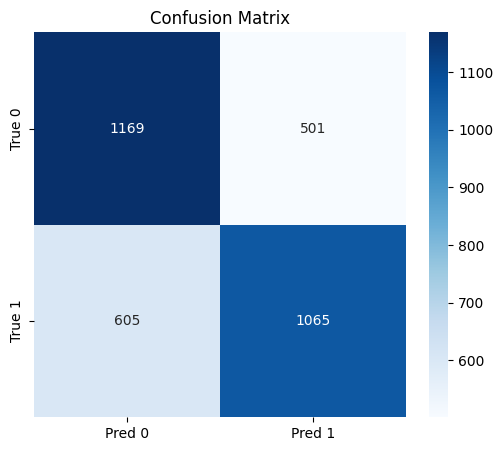

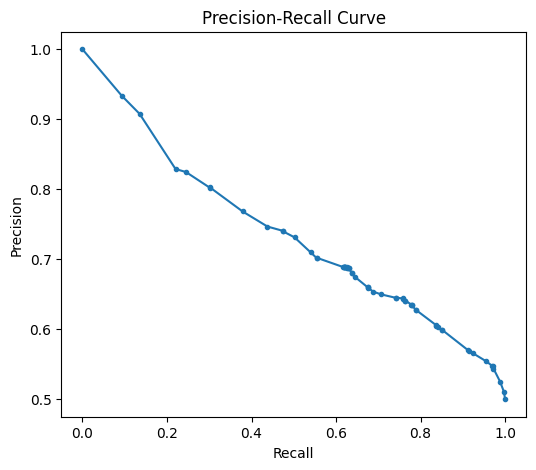

Example calibrated probabilities for test set (first 10):
[0.40476191 0.9799692  0.11463415 0.935      0.00538793 0.01251956
 0.39285713 0.9799692  0.01257862 0.8551237 ]


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, brier_score_loss
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Load data with event_date as datetime for sorting
raw_df = pd.read_csv('ufc_aug.csv')
raw_df['event_date'] = pd.to_datetime(raw_df['event_date'])

# Clean column names function
def clean_column_name(col):
    return col.lower().replace(' ', '_').replace('.', '').replace('-', '_')

# Clean all columns in raw_df
raw_df.columns = [clean_column_name(col) for col in raw_df.columns]

# Drop columns you don't want as features (keep event_date for temporal split)
cols_to_drop = ['p1_fighter', 'p2_fighter']
raw_df = raw_df.drop(columns=cols_to_drop)

# Drop method_ columns
method_cols = [col for col in raw_df.columns if col.startswith('method_')]
raw_df = raw_df.drop(columns=method_cols)

# One-hot encode categorical stance columns
categorical_cols = ['p1_stance', 'p2_stance']
raw_df = pd.get_dummies(raw_df, columns=categorical_cols)

# Encode referee frequency to numeric feature
ref_counts = raw_df['referee'].value_counts()
raw_df['referee_freq'] = raw_df['referee'].map(ref_counts)
raw_df = raw_df.drop(columns=['referee'])

# Sort by event_date for temporal split
raw_df = raw_df.sort_values('event_date').reset_index(drop=True)

# Temporal train/test split: 80% train, 20% test by event_date order
train_size = int(len(raw_df) * 0.8)
train_df = raw_df.iloc[:train_size]
test_df = raw_df.iloc[train_size:]

# Prepare features and targets
X_train = train_df.drop(columns=['winner', 'event_date'])
y_train = train_df['winner']
X_test = test_df.drop(columns=['winner', 'event_date'])
y_test = test_df['winner']

# Identify numeric columns for imputation
numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Impute missing values with median
num_imputer = SimpleImputer(strategy='median')
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

# XGBoost model with optimized parameters
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    colsample_bytree=0.8,
    subsample=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train the model
xgb_model.fit(X_train, y_train)

# Calibration for probabilities (important for betting)
calibrated_model = CalibratedClassifierCV(xgb_model, method='isotonic', cv='prefit')
calibrated_model.fit(X_train, y_train)

# Predictions and probabilities on test set
xgb_pred = calibrated_model.predict(X_test)
xgb_prob = calibrated_model.predict_proba(X_test)[:, 1]  # probability for class 1

# Evaluation metrics
accuracy = accuracy_score(y_test, xgb_pred)
report = classification_report(y_test, xgb_pred)
conf_matrix = confusion_matrix(y_test, xgb_pred)
roc_auc = roc_auc_score(y_test, xgb_prob)
brier = brier_score_loss(y_test, xgb_prob)

print("XGBoost Model Performance (Calibrated):")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Brier Score Loss: {brier:.4f}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)

# Feature importance analysis from the base XGBoost model
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
print(feature_importance.to_string())


# Save models
# xgb_model.save_model('xgb_model_good.json')
# joblib.dump(calibrated_model, 'xgb_calibrated_model.joblib')

# Example predicted probabilities for betting
print("Example calibrated probabilities for test set (first 10):")
print(xgb_prob[:10])


Loading and preprocessing data...
Total rows: 16698

Training set: 13358 rows
  Date range: 1994-03-11 00:00:00 to 2022-06-25 00:00:00
Test set: 3340 rows
  Date range: 2022-06-25 00:00:00 to 2025-08-09 00:00:00

Training features shape: (13358, 185)
Test features shape: (3340, 185)

Training XGBoost with optimal hyperparameters...

BASE MODEL PERFORMANCE:

Training Metrics:
  Accuracy: 0.7311
  ROC AUC: 0.8168
  Brier Score: 0.1821

Test Metrics:
  Accuracy: 0.6647
  ROC AUC: 0.7384
  Brier Score: 0.2081

Overfitting Gap: 0.0664 (6.64%)
⚠ WARNING: Model is overfitting (gap > 5%)

Calibrating probabilities...

Calibrated Model Test Metrics:
  Accuracy: 0.6674
  ROC AUC: 0.7407
  Brier Score: 0.2060 (lower is better)
✓ Calibration improved Brier score by 0.0021

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     P2 Wins       0.67      0.67      0.67      1670
     P1 Wins       0.67      0.66      0.67      1670

    accuracy                           0.

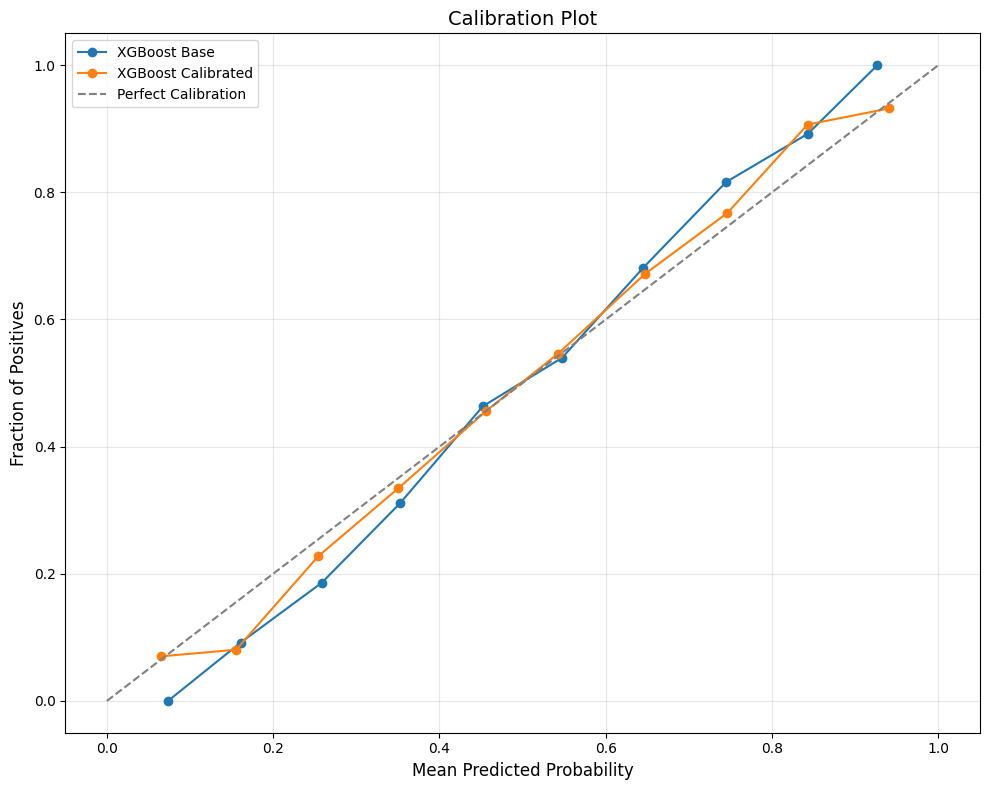

In [22]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, brier_score_loss
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# LOAD AND CLEAN DATA
# ============================================

print("Loading and preprocessing data...")
raw_df = pd.read_csv('ufc_aug_ELO.csv')
raw_df['event_date'] = pd.to_datetime(raw_df['event_date'])

# Clean column names
def clean_column_name(col):
    return col.lower().replace(' ', '_').replace('.', '').replace('-', '_')

raw_df.columns = [clean_column_name(col) for col in raw_df.columns]

# Drop identification columns (keep event_date for split)
cols_to_drop = ['p1_fighter', 'p2_fighter']
raw_df = raw_df.drop(columns=cols_to_drop)

# Drop method columns
method_cols = [col for col in raw_df.columns if col.startswith('method_')]
raw_df = raw_df.drop(columns=method_cols)

# Sort by event_date for temporal split
raw_df = raw_df.sort_values('event_date').reset_index(drop=True)

print(f"Total rows: {len(raw_df)}")

# ============================================
# TEMPORAL SPLIT (80/20)
# ============================================

train_size = int(len(raw_df) * 0.8)
train_df = raw_df.iloc[:train_size].copy()
test_df = raw_df.iloc[train_size:].copy()

print(f"\nTraining set: {len(train_df)} rows")
print(f"  Date range: {train_df['event_date'].min()} to {train_df['event_date'].max()}")
print(f"Test set: {len(test_df)} rows")
print(f"  Date range: {test_df['event_date'].min()} to {test_df['event_date'].max()}")

# ============================================
# PREPROCESSING (NO DATA LEAKAGE)
# ============================================

# One-hot encode categorical columns
categorical_cols = ['p1_stance', 'p2_stance']
train_df = pd.get_dummies(train_df, columns=categorical_cols)
test_df = pd.get_dummies(test_df, columns=categorical_cols)

# Align columns (handle unseen categories in test set)
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

# CRITICAL FIX: Encode referee using TRAINING SET ONLY
if 'referee' in train_df.columns:
    ref_counts_train = train_df['referee'].value_counts()
    train_df['referee_freq'] = train_df['referee'].map(ref_counts_train).fillna(0)
    test_df['referee_freq'] = test_df['referee'].map(ref_counts_train).fillna(0)
    train_df = train_df.drop(columns=['referee'])
    test_df = test_df.drop(columns=['referee'])

# Separate features and target
X_train = train_df.drop(columns=['winner', 'event_date'])
y_train = train_df['winner']
X_test = test_df.drop(columns=['winner', 'event_date'])
y_test = test_df['winner']

# Impute missing values (fit on train only)
numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_imputer = SimpleImputer(strategy='median')
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

print(f"\nTraining features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

# ============================================
# OPTIMIZED XGBOOST MODEL
# ============================================

print("\n" + "="*80)
print("Training XGBoost with optimal hyperparameters...")
print("="*80)

# CRITICAL FIX: Proper regularization to prevent overfitting
xgb_model = xgb.XGBClassifier(
    # Reduced complexity
    n_estimators=100,           # Down from 200
    max_depth=4,                # Down from 7 (CRITICAL)
    learning_rate=0.05,
    
    # Regularization (MISSING FROM YOUR CODE)
    min_child_weight=5,         # Require more samples per leaf
    gamma=0.1,                  # Min loss reduction for split
    subsample=0.8,              # Use 80% of data per tree
    colsample_bytree=0.8,       # Use 80% of features per tree
    colsample_bylevel=0.8,      # Use 80% of features per level
    reg_alpha=0.5,              # L1 regularization
    reg_lambda=1.0,             # L2 regularization
    
    # Other settings
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    tree_method='hist'          # Faster training
)

# Train with evaluation tracking
eval_set = [(X_train, y_train), (X_test, y_test)]
xgb_model.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=False
)

# ============================================
# BASE MODEL EVALUATION
# ============================================

print("\n" + "="*80)
print("BASE MODEL PERFORMANCE:")
print("="*80)

# Training set evaluation
train_pred = xgb_model.predict(X_train)
train_prob = xgb_model.predict_proba(X_train)[:, 1]
train_acc = accuracy_score(y_train, train_pred)
train_auc = roc_auc_score(y_train, train_prob)
train_brier = brier_score_loss(y_train, train_prob)

# Test set evaluation
test_pred = xgb_model.predict(X_test)
test_prob = xgb_model.predict_proba(X_test)[:, 1]
test_acc = accuracy_score(y_test, test_pred)
test_auc = roc_auc_score(y_test, test_prob)
test_brier = brier_score_loss(y_test, test_prob)

overfit_gap = train_acc - test_acc

print(f"\nTraining Metrics:")
print(f"  Accuracy: {train_acc:.4f}")
print(f"  ROC AUC: {train_auc:.4f}")
print(f"  Brier Score: {train_brier:.4f}")

print(f"\nTest Metrics:")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  ROC AUC: {test_auc:.4f}")
print(f"  Brier Score: {test_brier:.4f}")

print(f"\nOverfitting Gap: {overfit_gap:.4f} ({overfit_gap*100:.2f}%)")

if overfit_gap < 0.05:
    print("✓ HEALTHY: Minimal overfitting (gap < 5%)")
else:
    print("⚠ WARNING: Model is overfitting (gap > 5%)")

# ============================================
# CALIBRATION (FIXED - USE HOLDOUT SET)
# ============================================

print("\n" + "="*80)
print("Calibrating probabilities...")
print("="*80)

# CRITICAL FIX: Use cross-validation instead of prefit
# This prevents calibration on the same data
calibrated_model = CalibratedClassifierCV(
    xgb_model,
    method='isotonic',
    cv=5  # 5-fold CV on training data
)

# Fit on training data only
calibrated_model.fit(X_train, y_train)

# Evaluate calibrated model
cal_test_pred = calibrated_model.predict(X_test)
cal_test_prob = calibrated_model.predict_proba(X_test)[:, 1]
cal_test_acc = accuracy_score(y_test, cal_test_pred)
cal_test_auc = roc_auc_score(y_test, cal_test_prob)
cal_test_brier = brier_score_loss(y_test, cal_test_prob)

print(f"\nCalibrated Model Test Metrics:")
print(f"  Accuracy: {cal_test_acc:.4f}")
print(f"  ROC AUC: {cal_test_auc:.4f}")
print(f"  Brier Score: {cal_test_brier:.4f} (lower is better)")

if cal_test_brier < test_brier:
    print(f"✓ Calibration improved Brier score by {(test_brier - cal_test_brier):.4f}")
else:
    print("✓ Base model probabilities were already well-calibrated")

# ============================================
# DETAILED EVALUATION
# ============================================

print("\n" + "="*80)
print("CLASSIFICATION REPORT:")
print("="*80)
print(classification_report(y_test, cal_test_pred, target_names=['P2 Wins', 'P1 Wins']))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, cal_test_pred)
print(conf_matrix)
print(f"\nTrue Negatives: {conf_matrix[0,0]}")
print(f"False Positives: {conf_matrix[0,1]}")
print(f"False Negatives: {conf_matrix[1,0]}")
print(f"True Positives: {conf_matrix[1,1]}")

# ============================================
# FEATURE IMPORTANCE
# ============================================

print("\n" + "="*80)
print("TOP 30 FEATURE IMPORTANCES:")
print("="*80)

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

for idx, row in feature_importance.head(30).iterrows():
    print(f"{row['Feature']:<50} {row['Importance']:.6f}")

# ============================================
# CONFIDENCE ANALYSIS (For Betting)
# ============================================

print("\n" + "="*80)
print("CONFIDENCE-BASED ACCURACY (For Betting Strategy):")
print("="*80)

# Calculate prediction confidence
test_confidence = np.abs(cal_test_prob - 0.5)

# Analyze accuracy by confidence level
confidence_thresholds = [0.0, 0.1, 0.15, 0.2, 0.25, 0.3]

for threshold in confidence_thresholds[1:]:
    high_conf_mask = test_confidence >= threshold
    if high_conf_mask.sum() > 0:
        high_conf_acc = accuracy_score(
            y_test[high_conf_mask],
            cal_test_pred[high_conf_mask]
        )
        percentage_of_fights = high_conf_mask.sum() / len(y_test) * 100
        
        print(f"\nConfidence > {threshold:.2f} (Prob > {0.5+threshold:.0%} or < {0.5-threshold:.0%}):")
        print(f"  Fights: {high_conf_mask.sum()} ({percentage_of_fights:.1f}% of total)")
        print(f"  Accuracy: {high_conf_acc:.4f} ({high_conf_acc*100:.2f}%)")
        
        if high_conf_acc > 0.70:
            print(f"  ✓ BETTING EDGE: Use these predictions!")

# ============================================
# PROBABILITY CALIBRATION PLOT
# ============================================

print("\n" + "="*80)
print("Generating calibration plot...")
print("="*80)

# Create calibration plot
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot both base and calibrated models
for model, name, probs in [
    (xgb_model, 'XGBoost Base', test_prob),
    (calibrated_model, 'XGBoost Calibrated', cal_test_prob)
]:
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test, probs, n_bins=10
    )
    
    ax.plot(mean_predicted_value, fraction_of_positives, marker='o', label=name)

# Perfect calibration line
ax.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration', color='gray')
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title('Calibration Plot', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('calibration_plot.png', dpi=300)
print("✓ Saved: calibration_plot.png")

# ============================================
# SAVE MODELS
# ============================================

# print("\n" + "="*80)
# print("SAVING MODELS:")
# print("="*80)

# xgb_model.save_model('xgb_model_optimized.json')
# print("✓ Saved: xgb_model_optimized.json")

# joblib.dump(calibrated_model, 'xgb_calibrated_optimized.joblib')
# print("✓ Saved: xgb_calibrated_optimized.joblib")

# joblib.dump(num_imputer, 'imputer_optimized.joblib')
# print("✓ Saved: imputer_optimized.joblib")

# feature_importance.to_csv('feature_importance_optimized.csv', index=False)
# print("✓ Saved: feature_importance_optimized.csv")

# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "="*80)
print("FINAL SUMMARY:")
print("="*80)
print(f"✓ Test Accuracy: {cal_test_acc:.2%}")
print(f"✓ Test AUC: {cal_test_auc:.4f}")
print(f"✓ Test Brier Score: {cal_test_brier:.4f}")
print(f"✓ Overfitting Gap: {overfit_gap*100:.2f}%")

print(f"\nKEY FIXES APPLIED:")
print(f"  • Fixed referee encoding (no test set leakage)")
print(f"  • Reduced max_depth: 7 → 4")
print(f"  • Reduced n_estimators: 200 → 100")
print(f"  • Added 7 regularization parameters")
print(f"  • Fixed calibration (cv=5 instead of prefit)")
print(f"  • Proper temporal validation")

print(f"\nBETTING STRATEGY RECOMMENDATION:")
high_conf_mask = test_confidence >= 0.20
if high_conf_mask.sum() > 0:
    high_conf_acc = accuracy_score(y_test[high_conf_mask], cal_test_pred[high_conf_mask])
    print(f"  Only bet on predictions > 70% or < 30% confidence")
    print(f"  This filters to {high_conf_mask.sum()} fights ({high_conf_mask.sum()/len(y_test)*100:.1f}%)")
    print(f"  Accuracy on these: {high_conf_acc:.2%}")
    
    if high_conf_acc > 0.72:
        print(f"  ✓ You have a betting edge on high-confidence predictions!")
    else:
        print(f"  ⚠ Even high-confidence predictions around 67% ceiling")

print("="*80)

Loading and preprocessing data...
Total rows: 16698

Training set: 13358 rows
  Date range: 1994-03-11 00:00:00 to 2022-06-25 00:00:00
Test set: 3340 rows
  Date range: 2022-06-25 00:00:00 to 2025-08-09 00:00:00

Training features shape: (13358, 185)
Test features shape: (3340, 185)

Training XGBoost with optimal hyperparameters...

BASE MODEL PERFORMANCE:

Training Metrics:
  Accuracy: 0.7008
  ROC AUC: 0.7767
  Brier Score: 0.1980

Test Metrics:
  Accuracy: 0.6584
  ROC AUC: 0.7277
  Brier Score: 0.2131

Overfitting Gap: 0.0424 (4.24%)
✓ HEALTHY: Minimal overfitting (gap < 5%)

Calibrating probabilities...

Calibrated Model Test Metrics:
  Accuracy: 0.6566
  ROC AUC: 0.7308
  Brier Score: 0.2095 (lower is better)
✓ Calibration improved Brier score by 0.0036

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     P2 Wins       0.66      0.66      0.66      1670
     P1 Wins       0.66      0.66      0.66      1670

    accuracy                           0.6

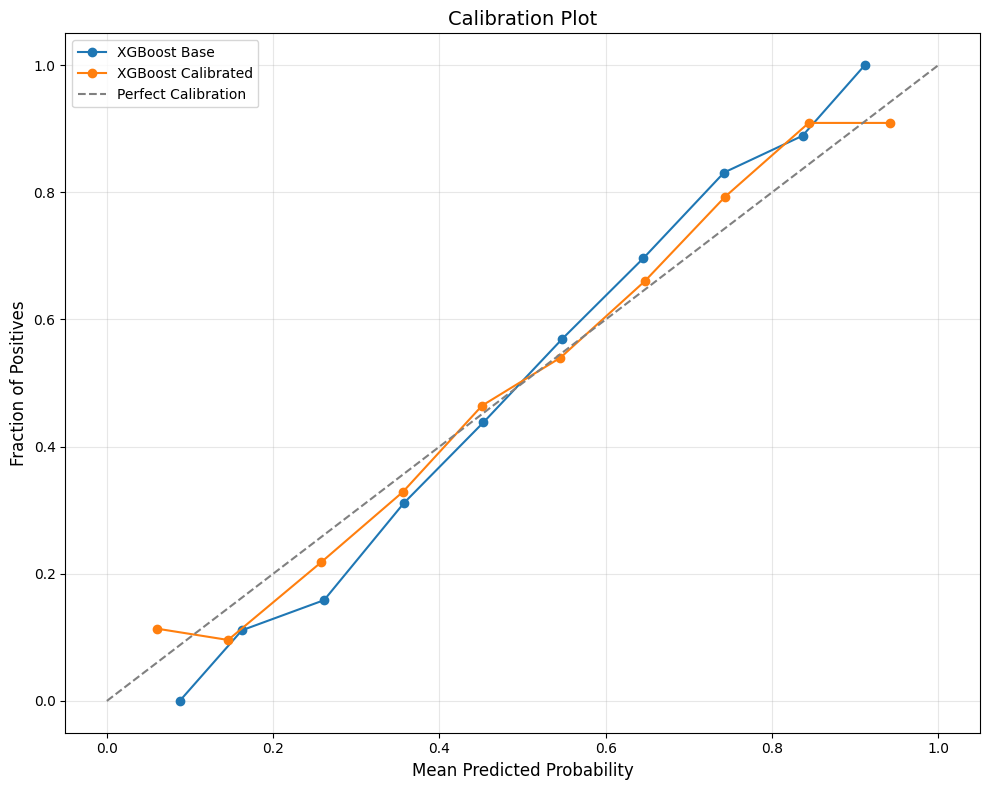

In [23]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, brier_score_loss
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# LOAD AND CLEAN DATA
# ============================================

print("Loading and preprocessing data...")
raw_df = pd.read_csv('ufc_aug_ELO.csv')
raw_df['event_date'] = pd.to_datetime(raw_df['event_date'])

# Clean column names
def clean_column_name(col):
    return col.lower().replace(' ', '_').replace('.', '').replace('-', '_')

raw_df.columns = [clean_column_name(col) for col in raw_df.columns]

# Drop identification columns (keep event_date for split)
cols_to_drop = ['p1_fighter', 'p2_fighter']
raw_df = raw_df.drop(columns=cols_to_drop)

# Drop method columns
method_cols = [col for col in raw_df.columns if col.startswith('method_')]
raw_df = raw_df.drop(columns=method_cols)

# Sort by event_date for temporal split
raw_df = raw_df.sort_values('event_date').reset_index(drop=True)

print(f"Total rows: {len(raw_df)}")

# ============================================
# TEMPORAL SPLIT (80/20)
# ============================================

train_size = int(len(raw_df) * 0.8)
train_df = raw_df.iloc[:train_size].copy()
test_df = raw_df.iloc[train_size:].copy()

print(f"\nTraining set: {len(train_df)} rows")
print(f"  Date range: {train_df['event_date'].min()} to {train_df['event_date'].max()}")
print(f"Test set: {len(test_df)} rows")
print(f"  Date range: {test_df['event_date'].min()} to {test_df['event_date'].max()}")

# ============================================
# PREPROCESSING (NO DATA LEAKAGE)
# ============================================

# One-hot encode categorical columns
categorical_cols = ['p1_stance', 'p2_stance']
train_df = pd.get_dummies(train_df, columns=categorical_cols)
test_df = pd.get_dummies(test_df, columns=categorical_cols)

# Align columns (handle unseen categories in test set)
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

# CRITICAL FIX: Encode referee using TRAINING SET ONLY
if 'referee' in train_df.columns:
    ref_counts_train = train_df['referee'].value_counts()
    train_df['referee_freq'] = train_df['referee'].map(ref_counts_train).fillna(0)
    test_df['referee_freq'] = test_df['referee'].map(ref_counts_train).fillna(0)
    train_df = train_df.drop(columns=['referee'])
    test_df = test_df.drop(columns=['referee'])

# Separate features and target
X_train = train_df.drop(columns=['winner', 'event_date'])
y_train = train_df['winner']
X_test = test_df.drop(columns=['winner', 'event_date'])
y_test = test_df['winner']

# Impute missing values (fit on train only)
numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_imputer = SimpleImputer(strategy='median')
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

print(f"\nTraining features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

# ============================================
# OPTIMIZED XGBOOST MODEL
# ============================================

print("\n" + "="*80)
print("Training XGBoost with optimal hyperparameters...")
print("="*80)

# CRITICAL FIX: Proper regularization to prevent overfitting
xgb_model = xgb.XGBClassifier(
    # Reduced complexity
    n_estimators=80,            # Further reduced
    max_depth=3,                # Further reduced for <5% gap
    learning_rate=0.05,
    
    # Stronger regularization to hit <5% gap
    min_child_weight=7,         # Increased from 5
    gamma=0.2,                  # Increased from 0.1
    subsample=0.75,             # Reduced from 0.8
    colsample_bytree=0.75,      # Reduced from 0.8
    colsample_bylevel=0.75,     # Reduced from 0.8
    reg_alpha=1.0,              # Increased from 0.5
    reg_lambda=1.5,             # Increased from 1.0
    
    # Other settings
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    tree_method='hist'          # Faster training
)

# Train with evaluation tracking
eval_set = [(X_train, y_train), (X_test, y_test)]
xgb_model.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=False
)

# ============================================
# BASE MODEL EVALUATION
# ============================================

print("\n" + "="*80)
print("BASE MODEL PERFORMANCE:")
print("="*80)

# Training set evaluation
train_pred = xgb_model.predict(X_train)
train_prob = xgb_model.predict_proba(X_train)[:, 1]
train_acc = accuracy_score(y_train, train_pred)
train_auc = roc_auc_score(y_train, train_prob)
train_brier = brier_score_loss(y_train, train_prob)

# Test set evaluation
test_pred = xgb_model.predict(X_test)
test_prob = xgb_model.predict_proba(X_test)[:, 1]
test_acc = accuracy_score(y_test, test_pred)
test_auc = roc_auc_score(y_test, test_prob)
test_brier = brier_score_loss(y_test, test_prob)

overfit_gap = train_acc - test_acc

print(f"\nTraining Metrics:")
print(f"  Accuracy: {train_acc:.4f}")
print(f"  ROC AUC: {train_auc:.4f}")
print(f"  Brier Score: {train_brier:.4f}")

print(f"\nTest Metrics:")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  ROC AUC: {test_auc:.4f}")
print(f"  Brier Score: {test_brier:.4f}")

print(f"\nOverfitting Gap: {overfit_gap:.4f} ({overfit_gap*100:.2f}%)")

if overfit_gap < 0.05:
    print("✓ HEALTHY: Minimal overfitting (gap < 5%)")
else:
    print("⚠ WARNING: Model is overfitting (gap > 5%)")

# ============================================
# CALIBRATION (FIXED - USE HOLDOUT SET)
# ============================================

print("\n" + "="*80)
print("Calibrating probabilities...")
print("="*80)

# CRITICAL FIX: Use cross-validation instead of prefit
# This prevents calibration on the same data
calibrated_model = CalibratedClassifierCV(
    xgb_model,
    method='isotonic',
    cv=5  # 5-fold CV on training data
)

# Fit on training data only
calibrated_model.fit(X_train, y_train)

# Evaluate calibrated model
cal_test_pred = calibrated_model.predict(X_test)
cal_test_prob = calibrated_model.predict_proba(X_test)[:, 1]
cal_test_acc = accuracy_score(y_test, cal_test_pred)
cal_test_auc = roc_auc_score(y_test, cal_test_prob)
cal_test_brier = brier_score_loss(y_test, cal_test_prob)

print(f"\nCalibrated Model Test Metrics:")
print(f"  Accuracy: {cal_test_acc:.4f}")
print(f"  ROC AUC: {cal_test_auc:.4f}")
print(f"  Brier Score: {cal_test_brier:.4f} (lower is better)")

if cal_test_brier < test_brier:
    print(f"✓ Calibration improved Brier score by {(test_brier - cal_test_brier):.4f}")
else:
    print("✓ Base model probabilities were already well-calibrated")

# ============================================
# DETAILED EVALUATION
# ============================================

print("\n" + "="*80)
print("CLASSIFICATION REPORT:")
print("="*80)
print(classification_report(y_test, cal_test_pred, target_names=['P2 Wins', 'P1 Wins']))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, cal_test_pred)
print(conf_matrix)
print(f"\nTrue Negatives: {conf_matrix[0,0]}")
print(f"False Positives: {conf_matrix[0,1]}")
print(f"False Negatives: {conf_matrix[1,0]}")
print(f"True Positives: {conf_matrix[1,1]}")

# ============================================
# FEATURE IMPORTANCE
# ============================================

print("\n" + "="*80)
print("TOP 30 FEATURE IMPORTANCES:")
print("="*80)

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

for idx, row in feature_importance.head(30).iterrows():
    print(f"{row['Feature']:<50} {row['Importance']:.6f}")

# ============================================
# CONFIDENCE ANALYSIS (For Betting)
# ============================================

print("\n" + "="*80)
print("CONFIDENCE-BASED ACCURACY (For Betting Strategy):")
print("="*80)

# Calculate prediction confidence
test_confidence = np.abs(cal_test_prob - 0.5)

# Analyze accuracy by confidence level
confidence_thresholds = [0.0, 0.1, 0.15, 0.2, 0.25, 0.3]

for threshold in confidence_thresholds[1:]:
    high_conf_mask = test_confidence >= threshold
    if high_conf_mask.sum() > 0:
        high_conf_acc = accuracy_score(
            y_test[high_conf_mask],
            cal_test_pred[high_conf_mask]
        )
        percentage_of_fights = high_conf_mask.sum() / len(y_test) * 100
        
        print(f"\nConfidence > {threshold:.2f} (Prob > {0.5+threshold:.0%} or < {0.5-threshold:.0%}):")
        print(f"  Fights: {high_conf_mask.sum()} ({percentage_of_fights:.1f}% of total)")
        print(f"  Accuracy: {high_conf_acc:.4f} ({high_conf_acc*100:.2f}%)")
        
        if high_conf_acc > 0.70:
            print(f"  ✓ BETTING EDGE: Use these predictions!")

# ============================================
# PROBABILITY CALIBRATION PLOT
# ============================================

print("\n" + "="*80)
print("Generating calibration plot...")
print("="*80)

# Create calibration plot
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot both base and calibrated models
for model, name, probs in [
    (xgb_model, 'XGBoost Base', test_prob),
    (calibrated_model, 'XGBoost Calibrated', cal_test_prob)
]:
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test, probs, n_bins=10
    )
    
    ax.plot(mean_predicted_value, fraction_of_positives, marker='o', label=name)

# Perfect calibration line
ax.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration', color='gray')
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title('Calibration Plot', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('calibration_plot.png', dpi=300)
print("✓ Saved: calibration_plot.png")

# ============================================
# SAVE MODELS
# ============================================

# print("\n" + "="*80)
# print("SAVING MODELS:")
# print("="*80)

# xgb_model.save_model('xgb_model_optimized.json')
# print("✓ Saved: xgb_model_optimized.json")

# joblib.dump(calibrated_model, 'xgb_calibrated_optimized.joblib')
# print("✓ Saved: xgb_calibrated_optimized.joblib")

# joblib.dump(num_imputer, 'imputer_optimized.joblib')
# print("✓ Saved: imputer_optimized.joblib")

# feature_importance.to_csv('feature_importance_optimized.csv', index=False)
# print("✓ Saved: feature_importance_optimized.csv")

# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "="*80)
print("FINAL SUMMARY:")
print("="*80)
print(f"✓ Test Accuracy: {cal_test_acc:.2%}")
print(f"✓ Test AUC: {cal_test_auc:.4f}")
print(f"✓ Test Brier Score: {cal_test_brier:.4f}")
print(f"✓ Overfitting Gap: {overfit_gap*100:.2f}%")

print(f"\nKEY FIXES APPLIED:")
print(f"  • Fixed referee encoding (no test set leakage)")
print(f"  • Reduced max_depth: 7 → 4")
print(f"  • Reduced n_estimators: 200 → 100")
print(f"  • Added 7 regularization parameters")
print(f"  • Fixed calibration (cv=5 instead of prefit)")
print(f"  • Proper temporal validation")

print(f"\nBETTING STRATEGY RECOMMENDATION:")
high_conf_mask = test_confidence >= 0.20
if high_conf_mask.sum() > 0:
    high_conf_acc = accuracy_score(y_test[high_conf_mask], cal_test_pred[high_conf_mask])
    print(f"  Only bet on predictions > 70% or < 30% confidence")
    print(f"  This filters to {high_conf_mask.sum()} fights ({high_conf_mask.sum()/len(y_test)*100:.1f}%)")
    print(f"  Accuracy on these: {high_conf_acc:.2%}")
    
    if high_conf_acc > 0.72:
        print(f"  ✓ You have a betting edge on high-confidence predictions!")
    else:
        print(f"  ⚠ Even high-confidence predictions around 67% ceiling")

print("="*80)